This notebook for Stardist applicationis adoptted from https://github.com/stardist/stardist/blob/main/examples/2D/3_prediction.ipynb

Students can use this as an initial notebook for more images with specific models and parameters.

Liya Ding 2024.10.01

In [1]:
import sys
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread, imwrite
from csbdeep.utils import normalize
from csbdeep.utils import download_and_extract_zip_file
import tifffile
from skimage.transform import resize

from cellpose import models, io


import pandas as pd
np.random.seed(6)


In [2]:
import os

In [3]:
root_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_raw/2.0 uM Tau (fig 4)/2.0 uM Tau (fig 4)/Fascin'

output_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/tau2_fig4_fascin'
processed_folder = output_folder+'/processed_MT/'

if not os.path.isdir(output_folder):   os.makedirs(output_folder)
if not os.path.isdir(processed_folder):   os.makedirs(processed_folder)

In [4]:
df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date', 'tau','fascin','a_actinin'])

folder_list = [x for x in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, x)) ]
for  folder_ID in range(len(folder_list)):
    sub_folder_name = folder_list[folder_ID]
    # print(sub_folder_name)
    sub_folder = os.path.join(root_folder, folder_list[folder_ID])
    
    # print(sub_folder)
    filename_list = [x for x in os.listdir(sub_folder)  if os.path.isfile(os.path.join(sub_folder, x)) and ('640.TIF' in x) ]
    for  filename_ID in range(len(filename_list)):
        MT_filename =  filename_list[filename_ID]

#### Liya fix the data for guv and them the following code parts, for figure 4 aactinin folder
# still need for another code for figure 4 fascin folder
# then go for the classification? maybe try that for the first groups to make sure the intensity profile thing doesn't hurt the performance


        if '2640' in MT_filename:
            GUV_filename = MT_filename.replace("2640.TIF","1561.TIF")
        if '3640' in MT_filename:
            GUV_filename = MT_filename.replace("3640.TIF","1561.TIF")  
        if '1640' in MT_filename:
            GUV_filename = MT_filename.replace("1640.TIF","3561.TIF") 
                 
        GUV_file_path = os.path.join(sub_folder, GUV_filename)
        MT_file_path = os.path.join(sub_folder, MT_filename)

        if(os.path.isfile(GUV_file_path) and os.path.isfile(MT_file_path)):
        ##########################
        # Liya check if both path exists                
            # print(file_path)                    
            s = pd.DataFrame([[sub_folder, GUV_filename,sub_folder, MT_filename, 'fascin','0', 2.0, float(sub_folder_name[6:10]), 0 ]],
                            columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date', 'tau','fascin','a_actinin'])
            df = pd.concat([df, s], ignore_index=True)
            # print(GUV_filename +' and '+ MT_filename)
        


/tmp/ipykernel_183063/4228736474.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, s], ignore_index=True)


In [5]:
df

,GUV_folder_path,GUV_file_name,MT_folder_path,MT_file_name,condition,date,tau,fascin,a_actinin
0,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV10_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV10_w2640.TIF,fascin,0,2.0,0.0,0
1,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV11_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV11_w2640.TIF,fascin,0,2.0,0.0,0
2,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV12_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV12_w2640.TIF,fascin,0,2.0,0.0,0
3,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV13_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV13_w2640.TIF,fascin,0,2.0,0.0,0
4,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV14_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV14_w2640.TIF,fascin,0,2.0,0.0,0
5,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV15_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV15_w2640.TIF,fascin,0,2.0,0.0,0
6,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV16_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV16_w2640.TIF,fascin,0,2.0,0.0,0
7,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV17_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV17_w2640.TIF,fascin,0,2.0,0.0,0
8,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV8_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV8_w2640.TIF,fascin,0,2.0,0.0,0
9,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV9_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV9_w2640.TIF,fascin,0,2.0,0.0,0


In [6]:
df.to_csv(os.path.join(output_folder,'df.csv'))

### Segmentation with cellpose pretrained models


In [7]:
# DEFINE CELLPOSE MODEL
# model_type='cyto3' or model_type='nuclei'
model = models.Cellpose(gpu=False, model_type='cyto3')



/home/ldin/anaconda3/envs/tf-gpu/lib/python3.9/site-packages/cellpose/resnet_torch.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, ma

In [8]:
from skimage.measure import label, regionprops, regionprops_table
from matplotlib import cm
from skimage import filters

In [9]:
from matplotlib import cm
# build the colormap with iterative tab10
tab10 = cm.get_cmap('tab10', 10)
for i in range(10):
    tab10.colors = np.concatenate([tab10.colors,tab10.colors],axis=0)    
tab10.colors = np.concatenate([np.zeros([1,4]),tab10.colors],axis=0)

newmap = cm.get_cmap('tab10', 200+1)
newmap.colors = tab10.colors[0:200+1,:]
newmap.colors[0,:]  = np.zeros([1,4])
newmap.colors[0,3] = 1

/tmp/ipykernel_183063/1700555406.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab10 = cm.get_cmap('tab10', 10)
/tmp/ipykernel_183063/1700555406.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  newmap = cm.get_cmap('tab10', 200+1)


In [10]:
im_width = 512

In [11]:
def norm_img(guv_img):
    vmin = np.percentile(guv_img.ravel(),0.2)
    vmax = np.percentile(guv_img.ravel(),99.8)
    output_img = np.clip(guv_img,vmin,vmax)
    output_img = (output_img - vmin)/(vmax-vmin)
    return output_img

In [12]:
number_img = len(df)
guv_img_all = np.zeros([number_img,im_width,im_width])
mt_img_all = np.zeros([number_img,im_width,im_width])

for row_ID in range(number_img): 
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
           
    # print(file_path)
    guv_img = imread(GUV_file_path)
    mt_img = imread(MT_file_path)
    if guv_img.ndim ==3:
        guv_img = guv_img.max(axis=0).squeeze()
    if mt_img.ndim ==3:
        mt_img = mt_img.max(axis=0).squeeze()


    guv_img[guv_img>2000]=1000

    guv_img_all[row_ID,0:guv_img.shape[0],0:guv_img.shape[1]] = norm_img(guv_img)
    mt_img_all[row_ID,0:mt_img.shape[0],0:mt_img.shape[1]] = norm_img(mt_img)
    

In [13]:
tifffile.imwrite(os.path.join(output_folder,'mt_img_all.tiff'),mt_img_all.astype(np.float32),
                 imagej=True,              # Write ImageJ metadata block
                metadata={'axes': 'ZYX'} )

In [14]:
guv_img_all[guv_img_all==0] = np.nan
mt_img_all[mt_img_all==0] = np.nan

In [15]:
guv_bg_img = np.nanmedian(guv_img_all, axis=0)
mt_bg_img = np.nanmedian(mt_img_all, axis=0)


from skimage.filters import median, gaussian
from skimage.morphology import disk

guv_bg_img_filtered = median(guv_bg_img, disk(5))
mt_bg_img_filtered  = median(mt_bg_img, disk(5))

# guv_bg_img_filtered_smooth = gaussian(guv_bg_img_filtered, 5)
# mt_bg_img_filtered_smooth = gaussian(mt_bg_img_filtered, 5)


/home/ldin/anaconda3/envs/tf-gpu/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


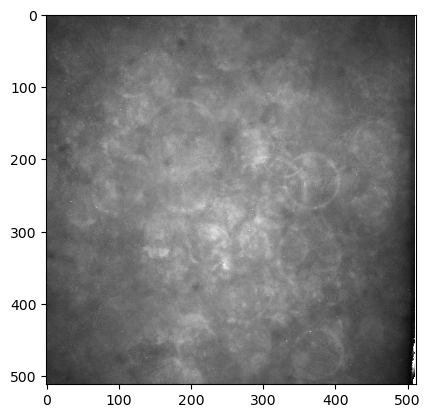

In [16]:
plt.imshow(guv_bg_img, clim=(0,0.2), cmap='gray')

In [17]:
guv_bg_int = np.nanmedian(guv_bg_img.ravel()) 
mt_bg_int = np.nanmedian(mt_bg_img.ravel()) 

(array([1.0627e+04, 4.9833e+04, 8.9165e+04, 8.2280e+04, 2.6732e+04,
        1.7420e+03, 1.4800e+02, 1.0000e+02, 6.0000e+01, 5.1000e+01,
        4.6000e+01, 3.5000e+01, 3.4000e+01, 3.6000e+01, 2.5000e+01,
        2.5000e+01, 2.3000e+01, 2.6000e+01, 2.1000e+01, 1.5000e+01,
        2.1000e+01, 1.8000e+01, 1.7000e+01, 1.0000e+01, 1.1000e+01,
        1.6000e+01, 2.1000e+01, 2.2000e+01, 1.6000e+01, 1.9000e+01,
        1.3000e+01, 1.1000e+01, 2.3000e+01, 1.0000e+01, 7.0000e+00,
        1.7000e+01, 1.8000e+01, 7.0000e+00, 1.6000e+01, 1.0000e+01,
        1.4000e+01, 1.0000e+01, 1.1000e+01, 1.0000e+01, 1.1000e+01,
        8.0000e+00, 1.5000e+01, 2.2600e+02]),
 array([0.00992797, 0.03055447, 0.05118097, 0.07180747, 0.09243397,
        0.11306047, 0.13368697, 0.15431347, 0.17493997, 0.19556648,
        0.21619298, 0.23681948, 0.25744598, 0.27807248, 0.29869898,
        0.31932548, 0.33995198, 0.36057848, 0.38120498, 0.40183148,
        0.42245798, 0.44308448, 0.46371098, 0.48433748, 0.50496398,
  

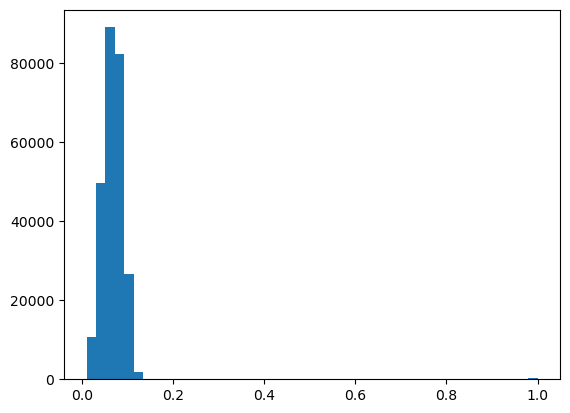

In [18]:
plt.hist(mt_bg_img.ravel(),bins=48)

In [19]:
mt_bg_int

0.06786650278723327

In [20]:
guv_bg_int

0.08690720082160788

In [21]:
# mt_bg_int = 122

In [22]:
# guv_bg_int = 110

In [23]:
guv_img_all.shape

(36, 512, 512)

In [24]:
guv_img_all = np.nan_to_num(guv_img_all, nan=guv_bg_int)
mt_img_all = np.nan_to_num(mt_img_all, nan=mt_bg_int)

In [25]:
pad_guv_img_all = np.zeros([number_img,im_width+128,im_width+128]) + guv_bg_int
guv_img_no_bg = np.zeros([number_img,im_width,im_width])

pad_mt_img_all = np.zeros([number_img,im_width+128,im_width+128]) + mt_bg_int
mt_img_no_bg = np.zeros([number_img,im_width,im_width])

for i in range(number_img):

    GUV_file_name = df.iloc[i]['GUV_file_name']
    condition = df.iloc[i]['condition']
    date = df.iloc[i]['date']
    tau = df.iloc[i]['tau']
    facin = df.iloc[i]['fascin']
    a_actinin = df.iloc[i]['a_actinin']
    
    fig1, ax1 = plt.subplots(2, 4, figsize=(16, 8))
    fig1.suptitle(condition+', '+date+', '+GUV_file_name)
    ax1[0,0].imshow(guv_bg_img,cmap='gray',vmin=80/512,vmax=500/512)
    ax1[0,0].axis('off')
    ax1[0,0].set_title('bg')
    ax1[0,1].imshow(guv_img_all[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[0,1].axis('off')
    ax1[0,1].set_title('org')
    # guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] 
    guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] - guv_bg_img_filtered + guv_bg_int
    
    ax1[0,2].imshow(guv_img_no_bg[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[0,2].axis('off')
    ax1[0,2].set_title('bg rm')
    pad_guv_img_all[i,64:64+im_width,64:64+im_width] = guv_img_no_bg[i,:,:]
    # pad_guv_img_all[i,:] = pad_guv_img_all[i,:] + 10
    ax1[0,3].imshow(pad_guv_img_all[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[0,3].axis('off')
    ax1[0,3].set_title('pd')

    ax1[1,0].imshow(mt_bg_img,cmap='gray',vmin=80/512,vmax=500/512)
    ax1[1,0].axis('off')
    ax1[1,0].set_title('bg')
    ax1[1,1].imshow(mt_img_all[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[1,1].axis('off')
    ax1[1,1].set_title('org')
    mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] - mt_bg_img_filtered + mt_bg_int
    # mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] 
    ax1[1,2].imshow(mt_img_no_bg[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[1,2].axis('off')
    ax1[1,2].set_title('bg rm')
    pad_mt_img_all[i,64:64+im_width,64:64+im_width] = mt_img_no_bg[i,:,:]
    # pad_mt_img_all[i,:] = pad_mt_img_all[i,:] + 10
    ax1[1,3].imshow(pad_mt_img_all[i,:,:],cmap='gray',vmin=80/512,vmax=500/512)
    ax1[1,3].axis('off')
    ax1[1,3].set_title('pd')

    fig1.savefig(processed_folder+'pre-processed-guv-mt-'+ str(i).zfill(2) +'.jpg')
    plt.close(fig1)


In [26]:
stardist_display_folder =  processed_folder + 'GUV-MT_obj_detect_filter_selected_std15'
obj_crop_panel_folder = processed_folder + 'GUV-MT_obj_panel_selected_std15'
tiff_folder= processed_folder + 'GUV-MT_obj_tiff_selected_std15'
png_folder= processed_folder + 'GUV-MT_obj_png_selected_std15'  
singlecell_annotation_folder = processed_folder + 'singlecell_annotation_selected_std15' 

if not os.path.isdir(stardist_display_folder):   os.makedirs(stardist_display_folder)
if not os.path.isdir(obj_crop_panel_folder):   os.makedirs(obj_crop_panel_folder)
if not os.path.isdir(tiff_folder):   os.makedirs(tiff_folder)
if not os.path.isdir(png_folder):   os.makedirs(png_folder)
os.makedirs(singlecell_annotation_folder, exist_ok=True)

In [27]:
mt_img_medianfiltered = median(mt_img, disk(3))

In [28]:
sigma=1

In [29]:
guv_img_all_smooth = guv_img_all.copy()
mt_img_all_smooth = mt_img_all.copy()
for row_ID in range(df.shape[0]): 
    guv_img_all_smooth = filters.gaussian(guv_img_all[row_ID], sigma)
    mt_img_all_smooth = filters.gaussian(mt_img_all[row_ID], sigma)    

guv_1p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.001)
guv_99p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.99)
mt_1p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.001)
mt_99p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.99)



In [30]:
(mt_bg_int-mt_1p)/(mt_99p-mt_1p)

0.06185407066434838

In [31]:
mt_bg_int = 0.082
(mt_bg_int-mt_1p)/(mt_99p-mt_1p)*255

19.400076539621598

In [32]:
mt_1p

0.006408845292483011

In [33]:
mt_99p

1.0

In [34]:
too_small_int = mt_bg_int
normed_too_small_int = (too_small_int-mt_1p)/(mt_99p-mt_1p)

In [35]:
normed_too_small_int

0.07607873152792784

In [36]:
normed_too_small_int*255

19.400076539621598

In [37]:
df

,GUV_folder_path,GUV_file_name,MT_folder_path,MT_file_name,condition,date,tau,fascin,a_actinin
0,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV10_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV10_w2640.TIF,fascin,0,2.0,0.0,0
1,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV11_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV11_w2640.TIF,fascin,0,2.0,0.0,0
2,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV12_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV12_w2640.TIF,fascin,0,2.0,0.0,0
3,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV13_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV13_w2640.TIF,fascin,0,2.0,0.0,0
4,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV14_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV14_w2640.TIF,fascin,0,2.0,0.0,0
5,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV15_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV15_w2640.TIF,fascin,0,2.0,0.0,0
6,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV16_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV16_w2640.TIF,fascin,0,2.0,0.0,0
7,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV17_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV17_w2640.TIF,fascin,0,2.0,0.0,0
8,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV8_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV8_w2640.TIF,fascin,0,2.0,0.0,0
9,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV9_w1561.TIF,/mnt/d/lding/CLS/mousumiLiuDinner/revision_dat...,GUV9_w2640.TIF,fascin,0,2.0,0.0,0


In [38]:
cell_cropped_array =np.zeros([2000,96,96])
cell_cropped_cellalone_array =np.zeros([2000,96,96])
cell_ind=0
plt.rcParams.update({'font.size': 16})
sigma = 1

# guv_img = guv_img*400
# mt_img = mt_img*400

cell_index = 0
    
cell_df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','cell_ID','cell_index','cx','cy','diameter','bbox_1','bbox_2','bbox_3','bbox_4','obj_folder','obj_filename'])

for row_ID in range(df.shape[0]): 
# for row_ID in range(20): 
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
    
    GUV_folder_path = df.iloc[row_ID]['GUV_folder_path']
    MT_folder_path = df.iloc[row_ID]['MT_folder_path']
    GUV_file_name = df.iloc[row_ID]['GUV_file_name']
    MT_file_name = df.iloc[row_ID]['MT_file_name']
    condition = df.iloc[row_ID]['condition']
    date = df.iloc[row_ID]['date']
    tau = df.iloc[row_ID]['tau']
    fascin = df.iloc[row_ID]['fascin']
    a_actinin = df.iloc[row_ID]['a_actinin']
    print(tau)
    
    
    guv_img = guv_img_all[row_ID,:,:]

    





    mt_img = mt_img_all[row_ID,:,:]
    mt_img_medianfiltered = median(mt_img, disk(3))
    # img = imread(file_path)
    # img = np.sqrt(img)
    guv_smooth = filters.gaussian(guv_img, sigma)
    guv_img_normed = normalize(guv_smooth,1,99)
    mt_smooth = filters.gaussian(mt_img_medianfiltered, sigma)
    guv_img_normed = (guv_smooth-guv_1p)/(guv_99p-guv_1p)
    guv_img_normed[guv_img_normed<0] = 0
    guv_img_normed[guv_img_normed>1] = 1
    mt_img_normed = (mt_smooth-mt_1p)/(mt_99p-mt_1p)/(1.7)
    mt_img_normed[mt_img_normed<0] = 0
    mt_img_normed[mt_img_normed>1] = 1
    
    guv_mt_img = np.zeros([2,im_width,im_width])
    guv_mt_img[0,:] = guv_img_normed
    guv_mt_img[1,:] = mt_img_normed
    
    guv_img_pad = pad_guv_img_all[row_ID,:,:]
    mt_img_pad = pad_mt_img_all[row_ID,:,:]
    mt_img_pad = median(mt_img_pad, disk(3))
    
       # cellpose
    labels, flows, styles, diams = model.eval(guv_mt_img[:,::2,::2],channels=[1,2])
    us_manual = np.zeros([im_width,im_width])
    us_manual[::2,::2]=labels
    us_manual[1::2,::2]=labels[:,:]
    us_manual[::2,1::2]=labels[:,:]
    us_manual[1::2,1::2]=labels[:us_manual[1::2,1::2].shape[0],:us_manual[1::2,1::2].shape[1]]
    
    labels = us_manual.astype(int)
    
    fig2, ax2 = plt.subplots(2, 3, figsize=(16, 8))
    fig2.suptitle(condition+', '+date+', '+GUV_file_name)
    ax2[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
    ax2[0,0].axis('off')
    ax2[0,0].set_title('GUV')
    ax2[0,1].imshow(guv_img_normed, clim=(0,1), cmap='gray')
    ax2[0,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[0,1].axis('off')
    ax2[0,1].set_title('Segmentation')
    
    ax2[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
    ax2[1,0].axis('off')
    ax2[1,0].set_title('MT')
    
    ax2[1,1].imshow(mt_img_normed, clim=(0,1), cmap='gray')
    ax2[1,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[1,1].axis('off')
    ax2[1,1].set_title('Segmentation')

    regionprops_pax = regionprops(labels,intensity_image=mt_img)

    bad_region_flag = np.zeros(labels.max())

    for region_i in range(0,labels.max()):
        # print([regionprops_pax[region_i]['Area'],regionprops_pax[region_i]['Eccentricity']])
        if(regionprops_pax[region_i]['Eccentricity']>0.5 or regionprops_pax[region_i]['Area']<1000 or regionprops_pax[region_i]['Area']>40000):
            bad_region_flag[region_i]=1
            labels[labels==region_i+1] =0
            continue
        else:
            img_content = mt_img_medianfiltered[labels==region_i+1]
            img_content = img_content[img_content>mt_bg_int]
            if(img_content.shape[0] == 0):
                bad_region_flag[region_i] = 1
                labels[labels==region_i+1] = 0       
                continue
            else:
                # print(img_content.std())
                if(img_content.std()<15/400):
                    bad_region_flag[region_i] = 1
                    labels[labels==region_i+1] = 0       
                    continue

    
    ax2[0,2].imshow(guv_img_normed, clim=(0,1), cmap='gray')
    ax2[0,2].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[0,2].axis('off')
    ax2[0,2].set_title('filtered')


    ax2[1,2].imshow(mt_img_normed, clim=(0,1), cmap='gray')
    # ax2[1,2].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[1,2].axis('off')
    ax2[1,2].set_title('filtered')

   
    if labels.max() == 0:   
        fig2.savefig(os.path.join(stardist_display_folder, condition+'-'+date+'-'+GUV_file_name+'_cellpose_filter.png'))
        plt.close(fig2)     
        continue
    
    labels_pad = np.zeros_like(guv_img_pad)
    labels_pad[64:64+im_width,64:64+im_width] = labels
    

    fig3, ax3 = plt.subplots(1, int(len(regionprops_pax) -bad_region_flag.sum()), figsize=(12, 6))

    fig3.suptitle(condition+', '+date+', ' + GUV_file_name)
    good_ind = 0
    for obj_i in range(len(regionprops_pax)):
        if(bad_region_flag[obj_i]>0):
            continue
        good_ind = good_ind + 1
        Centroid = regionprops_pax[obj_i]['Centroid']
        BBox = regionprops_pax[obj_i]['bbox']
        Area = regionprops_pax[obj_i]['area']
        Diameter = regionprops_pax[obj_i]['equivalent_diameter_area']
        cell_ID = regionprops_pax[obj_i]['label']
        
        cx = round(Centroid[0]) + 64
        cy = round(Centroid[1]) + 64


        mt_img_pad = np.zeros([im_width+128,im_width+128]) + (mt_bg_int-mt_1p)/(mt_99p-mt_1p)
        mt_img_pad[64:-64,64:-64] = mt_img_normed

        crop_img = mt_img_pad[cx-48:cx+48,cy-48:cy+48]
        crop_label = (labels_pad[cx-48:cx+48,cy-48:cy+48]).copy().astype(float)


        radius_estimated = Diameter/2
        circle = plt.Circle((cy-64+1, cx-64+1), radius_estimated, color=newmap.colors[obj_i+1,:], fill=False, linewidth=3)
        ax2[1,2].add_patch(circle)


        # Liya to do : match the intensity range with old set

        
        crop_img_cellalone = np.zeros_like(crop_img) + (mt_bg_int-mt_1p)/(mt_99p-mt_1p)
        # crop_img_cellalone = np.zeros_like(crop_img) + 19.68
        too_small_int = 0.08
        normed_too_small_int = (too_small_int-mt_1p)/(mt_99p-mt_1p)
        
        mask = crop_label==cell_ID
        mask_smooth = filters.gaussian(mask.astype(float), sigma)
        mask_smooth_bw = mask_smooth>0.1

        crop_img_cellalone[mask_smooth_bw>0] = crop_img[mask_smooth_bw>0] 
        crop_img_cellalone[crop_img_cellalone<normed_too_small_int]=normed_too_small_int
        


        cell_cropped_array[cell_ind,:,:] = crop_img*400
        cell_cropped_cellalone_array[cell_ind,:,:]=crop_img_cellalone
        cell_ind = cell_ind+1

        if len(regionprops_pax) -bad_region_flag.sum() == 1:
            ax3.imshow(crop_img_cellalone,cmap='gray',vmin=20,vmax=400)
            ax3.axis('off')
            ax3.set_title('obj '+str(good_ind).zfill(2))
        else:
            ax3[good_ind-1].imshow(crop_img_cellalone,cmap='gray',vmin=20,vmax=400)
            ax3[good_ind-1].axis('off')
            ax3[good_ind-1].set_title('obj '+str(good_ind).zfill(2))

        cell_index = cell_index + 1       
        

        fig4, ax4 = plt.subplots(2, 3, figsize=(12, 8))
        fig4.suptitle(condition+', '+date+', '+GUV_file_name)
        ax4[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
        ax4[0,0].axis('off')
        ax4[0,0].set_title('img')    
        ax4[0,0].set_title('GUV')
    
        ax4[0,1].imshow(guv_img_normed, clim=(0,1), cmap='gray')
        ax4[0,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
        ax4[0,1].axis('off')
        ax4[0,1].set_title('filtered')

        ax4[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
        ax4[1,0].axis('off')
        ax4[1,0].set_title('MT')

        ax4[1,1].imshow(mt_img_normed, clim=(0,1), cmap='gray')
        ax4[1,1].axis('off')       
        circle4 = plt.Circle((cy-64+1, cx-64+1), radius_estimated, color=newmap.colors[obj_i+1,:], fill=False, linewidth=3)         
        ax4[1,1].add_patch(circle4)
        ax4[1,1].set_title('In this image: Cell ' + str(cell_ID).zfill(2)  )
        
        ax4[0,2].axis('off') 
        ax4[0,2].set_title('All cell index='+str(cell_index).zfill(4))
        
        display_image = crop_img_cellalone 
        # display_image = display_image/(3)
        # display_image[display_image<0]=0
        # display_image[display_image>255]=255
        
        ax4[1,2].imshow(display_image, clim=(0,1), cmap='gray')
        ax4[1,2].set_title('Cropped object')
        ax4[1,2].axis('off') 
        
        

        fig4.savefig(os.path.join(singlecell_annotation_folder, condition+'-'+date+'-'+GUV_file_name+'_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.png'))
        plt.close(fig4)



        # obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.png'
        # tifffile.imsave(os.path.join(png_folder, obj_filename),crop_img.astype(np.float16))  
        
        # obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.tif'
        # tifffile.imwrite(os.path.join(tiff_folder, obj_filename),crop_img.astype(np.float16))  


        display_image = display_image*255
        display_image[display_image>=255]=254

        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.png'
        tifffile.imwrite(os.path.join(png_folder, obj_filename),np.clip(display_image, 0, 255).astype(np.uint8))  
        

        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.tif'
        
        tifffile.imwrite(
            os.path.join(tiff_folder, obj_filename),
            crop_img_cellalone.astype(np.float32),
            imagej=True,             
            metadata={'axes': 'YX'}  
        )  

    
        s = pd.DataFrame([[GUV_folder_path, GUV_file_name, MT_folder_path, MT_file_name, condition,date,tau,fascin,a_actinin,cell_ID, cell_index,Centroid[0],Centroid[1],Diameter,BBox[0],BBox[1],BBox[2],BBox[3],tiff_folder,obj_filename]],
                         columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','tau','fascin','a_actinin','cell_ID','cell_index','cx','cy','diameter','bbox_1','bbox_2','bbox_3','bbox_4','obj_folder','obj_filename'])
        
        cell_df = pd.concat([cell_df, s], ignore_index=True)

    fig2.savefig(os.path.join(stardist_display_folder, condition+'-'+date+'-'+GUV_file_name+'_cellpose_filter.png'))
    plt.close(fig2)    

    fig3.savefig(os.path.join(obj_crop_panel_folder, condition+'-'+date+'-'+GUV_file_name+'_guv_mt_obj_crop_panel.png'))    
    plt.close(fig3)

# tifffile.imwrite(os.path.join(processed_folder, 'mt_all_cell_cropped_array.tiff'),cell_cropped_array.astype(np.float16))  
# tifffile.imwrite(os.path.join(processed_folder, 'mt_all_cellalone_cropped_array.tiff'),cell_cropped_cellalone_array.astype(np.float16))  


2.0


/tmp/ipykernel_183063/3736448148.py:267: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cell_df = pd.concat([cell_df, s], ignore_index=True)


2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0
2.0


In [39]:
png_folder

'/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/tau2_fig4_fascin/processed_MT/GUV-MT_obj_png_selected_std15'

In [40]:


normed_too_small_int

0.07406583116088628

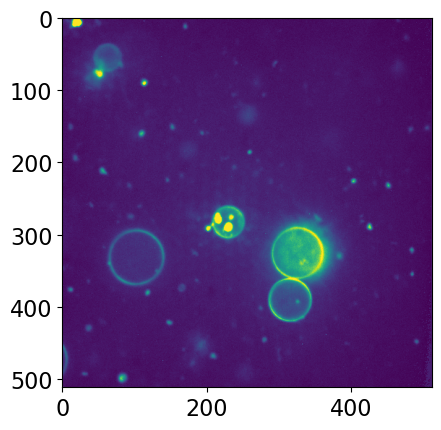

In [41]:
plt.imshow(guv_img)


In [42]:
cell_df['tau']

0      2.0
1      2.0
2      2.0
3      2.0
4      2.0
      ... 
142    2.0
143    2.0
144    2.0
145    2.0
146    2.0
Name: tau, Length: 147, dtype: float64

In [43]:
cell_df.to_csv(os.path.join(processed_folder, 'facin_guv_mt_cell_df_circle_selected_std15.csv'))

In [44]:
os.path.join(processed_folder, 'facin_guv_mt_cell_df_circle_selected_std15.csv')

'/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/tau2_fig4_fascin/processed_MT/facin_guv_mt_cell_df_circle_selected_std15.csv'

In [45]:
os.path.join(processed_folder, 'facin_guv_mt_cell_df_circle_selected_std15.csv')

'/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/tau2_fig4_fascin/processed_MT/facin_guv_mt_cell_df_circle_selected_std15.csv'

In [46]:
tifffile.imwrite(os.path.join(processed_folder, 'facin_mt_all_cellalone_cropped_array_selected_std15.tiff'),cell_cropped_cellalone_array.astype(np.float16))  

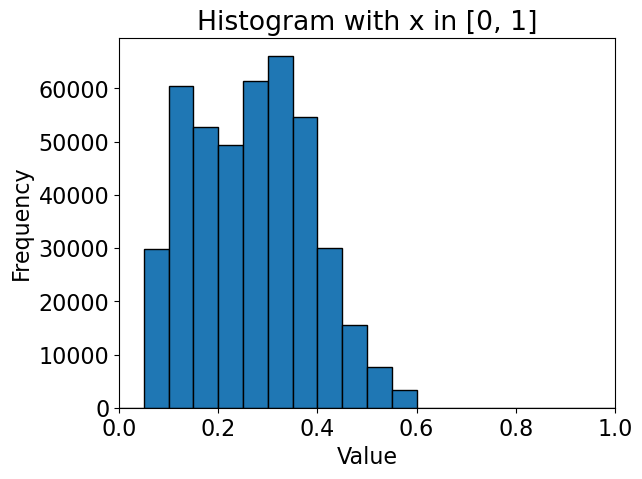

In [47]:

bins = np.linspace(0, 1, 21)  # 20 bins between 0 and 1

plt.hist(cell_cropped_cellalone_array[cell_cropped_cellalone_array>0.078], bins=bins, edgecolor='black')
plt.xlim(0, 1)  # Set x-axis to [0, 1]
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with x in [0, 1]")
plt.show()